In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [3]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
def build_model(num_layers=2,
                neurons=64,
                activation='relu',
                optimizer='adam',
                learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons,
                    activation=activation,
                    input_shape=(X_train.shape[1],)))

    for i in range(num_layers-1):
        model.add(Dense(neurons,
                        activation=activation))

    model.add(Dense(1))

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)

    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
    )

    return model

In [6]:
learning_rates = [0.001, 0.0005]

batch_sizes = [32, 64]

layers = [2,3]

activations = ['relu','tanh']

optimizers = ['adam','sgd','rmsprop']

In [ ]:
results = []

best_mae = 999
best_model = None

for lr in learning_rates:

    for batch in batch_sizes:

        for layer in layers:

            for act in activations:

                for opt in optimizers:

                    print("="*60)
                    print("Learning Rate:",lr)
                    print("Batch Size:",batch)
                    print("Layers:",layer)
                    print("Activation:",act)
                    print("Optimizer:",opt)

                    model = build_model(
                        num_layers=layer,
                        activation=act,
                        optimizer=opt,
                        learning_rate=lr
                    )

                    history = model.fit(
                        X_train,
                        y_train,
                        epochs=20,
                        batch_size=batch,
                        validation_split=0.2,
                        verbose=0
                    )

                    val_mae = history.history['val_mae'][-1]
                    val_loss = history.history['val_loss'][-1]

                    results.append([
                        lr,
                        batch,
                        layer,
                        act,
                        opt,
                        val_mae,
                        val_loss
                    ])

                    print("Validation MAE:",val_mae)

                    if val_mae < best_mae:
                        best_mae = val_mae
                        best_model = model

In [ ]:
results_df = pd.DataFrame(results,
                          columns=[
                              "Learning Rate",
                              "Batch Size",
                              "Layers",
                              "Activation",
                              "Optimizer",
                              "Validation MAE",
                              "Validation Loss"
                          ])

print(results_df)

In [9]:
best = results_df.sort_values(
    by="Validation MAE"
).head(1)

print(best)

   Learning Rate  Batch Size  Layers Activation Optimizer  Validation MAE  \
9          0.001          32       3       tanh      adam         0.37254   

   Validation Loss  
9         0.293463  


In [10]:
loss, mae = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test MAE:",mae)
print("Test Loss:",loss)

Test MAE: 0.3659116327762604
Test Loss: 0.2831241488456726


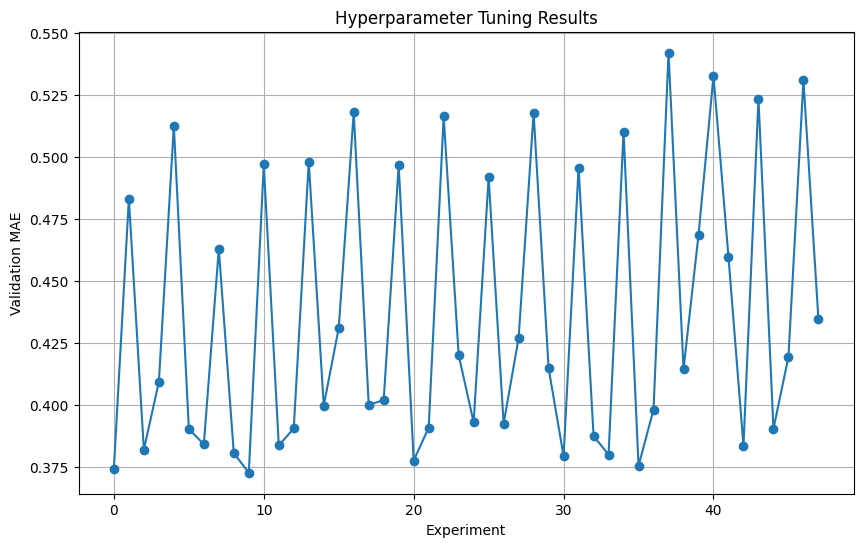

In [11]:
plt.figure(figsize=(10,6))

plt.plot(results_df["Validation MAE"],marker='o')

plt.xlabel("Experiment")

plt.ylabel("Validation MAE")

plt.title("Hyperparameter Tuning Results")

plt.grid(True)

plt.show()

In [12]:
best_model.save("best_housing_model.keras")